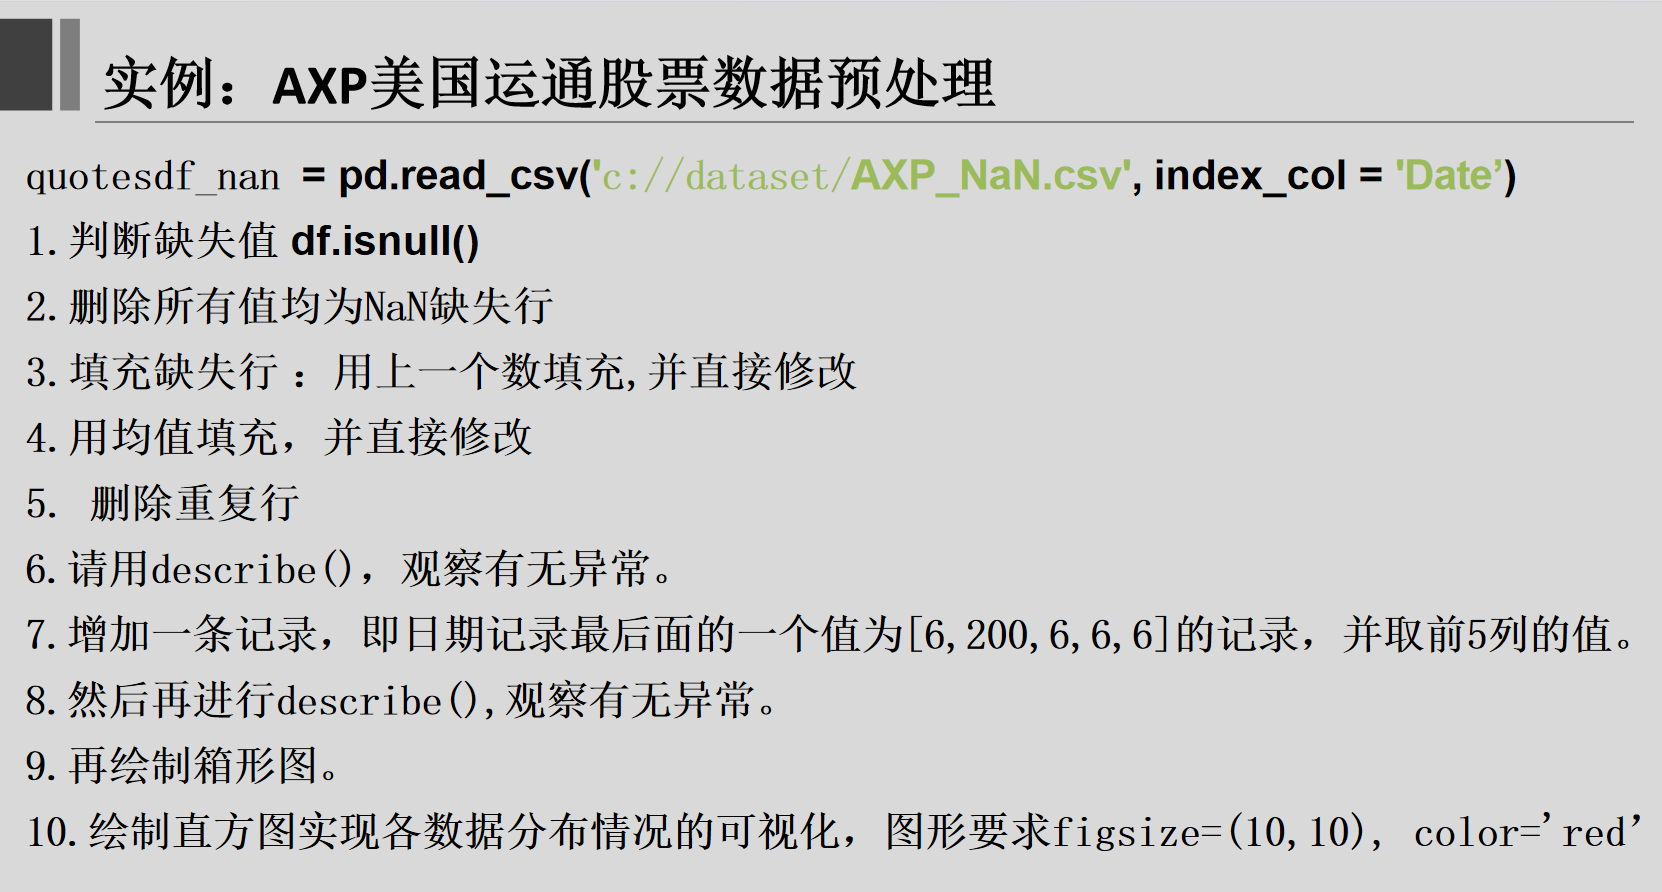

# AXP美国运通股票数据预处理

# 导入模块

In [ ]:
import pandas as pd

# 获取数据

In [6]:
import chardet
# 读取数据
file = '../data/AXP_nan.csv'
with open(file, 'rb') as f:
    result = chardet.detect(f.read())
    print(result)

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [7]:
quotesdf_nan = pd.read_csv(file, index_col = 'Date', encoding=result['encoding']) 
                                                      #Date列设置为索引列
print(quotesdf_nan)
quotesdf_nan

                 Open        High         Low       Close   Adj Close   Volume
Date                                                                          
2018-6-1    99.339996   99.610001   98.220001   98.250000   94.120537  2711200
2018-6-4    98.809998   99.510002   98.639999   99.449997   95.270088  2417400
2018-6-5    99.120003   99.410004   98.430000   99.309998   95.135979  1811500
2018-6-6   100.000000  101.000000   99.570000  100.970001   96.726196  2872700
2018-6-7   101.440002  102.389999  100.889999  101.480003   97.214767  4245700
...               ...         ...         ...         ...         ...      ...
2021-3-26  143.740005  143.979996  141.050003  143.729996  143.729996  2687000
2021-3-29  141.979996  143.070007  140.309998  142.369995  142.369995  2220600
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-31         NaN  143.259995         NaN  141.4

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600
2021-3-30,142.899994,144.479996,142.610001,143.490005,143.490005,2034500


# 1.判断缺失值 df.isnull()  

In [8]:
quotesdf_nan.isnull()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,False,False,False,False,False,False
2018-6-4,False,False,False,False,False,False
2018-6-5,False,False,False,False,False,False
2018-6-6,False,False,False,False,False,False
2018-6-7,False,False,False,False,False,False
...,...,...,...,...,...,...
2021-3-26,False,False,False,False,False,False
2021-3-29,False,False,False,False,False,False
2021-3-30,False,False,False,False,False,False


In [9]:
quotesdf_nan.isnull().sum()

Open         1
High         0
Low          1
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
print(quotesdf_nan.shape) #用df.shape看数据的每个维度的数量
quotesdf_nan.info();  #用df.info()看数据的基本情况

(714, 6)
<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2018-6-1 to 2021-3-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       713 non-null    float64
 1   High       714 non-null    float64
 2   Low        713 non-null    float64
 3   Close      714 non-null    float64
 4   Adj Close  714 non-null    float64
 5   Volume     714 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 39.0+ KB


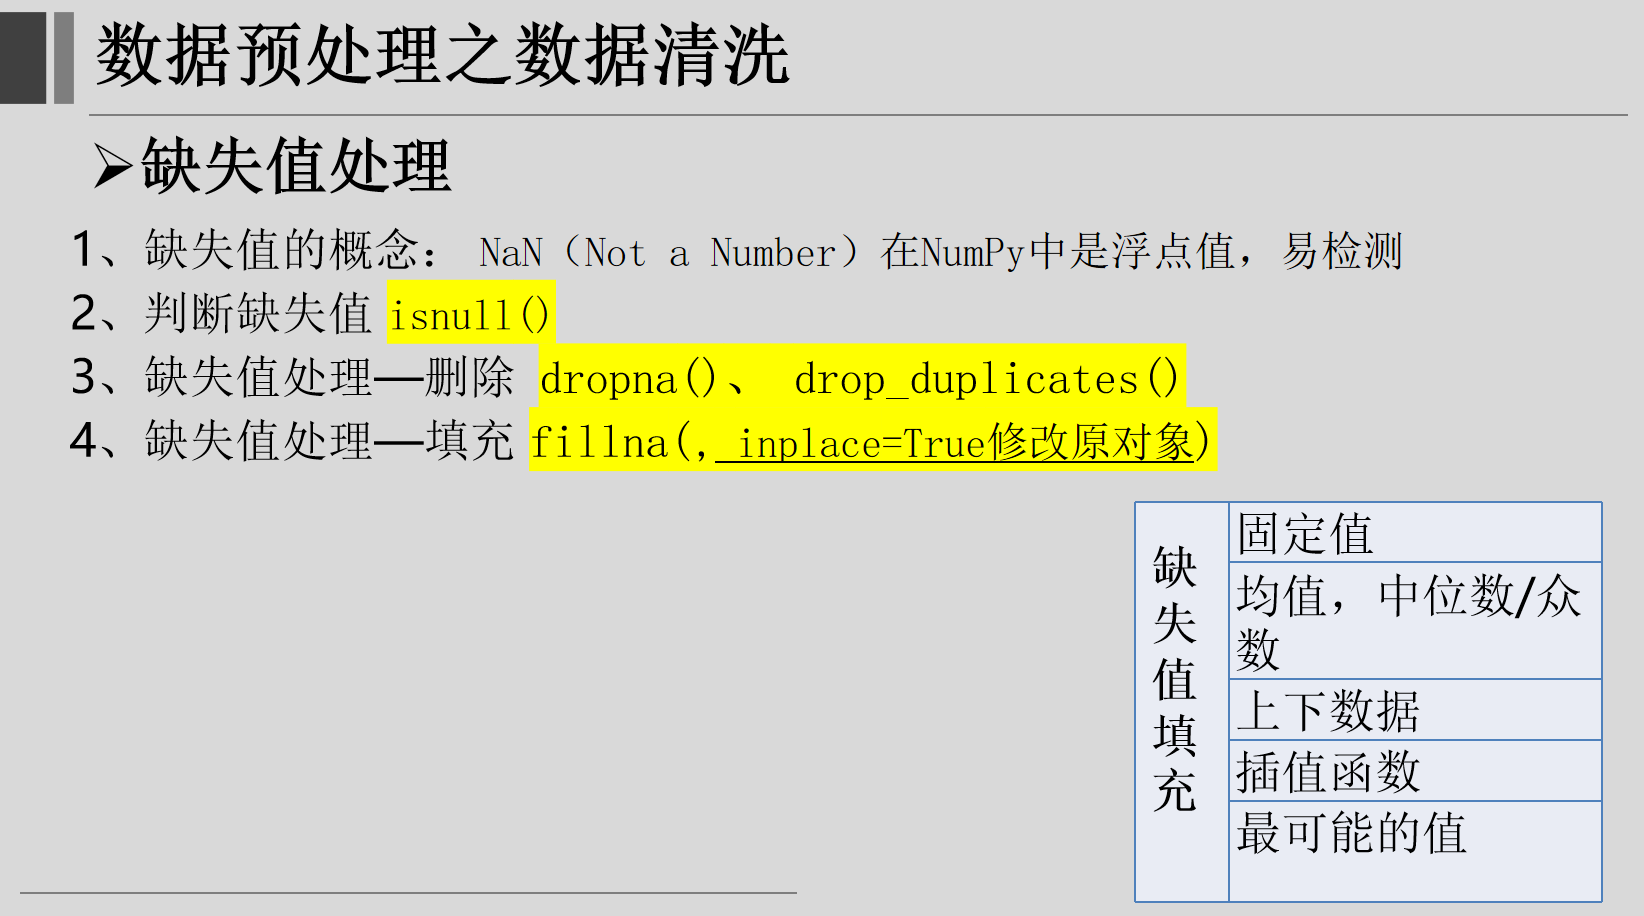


# 2.删除所有值均为NaN缺失行

In [11]:
quotesdf_nan.dropna(how="all") 

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600
2021-3-30,142.899994,144.479996,142.610001,143.490005,143.490005,2034500


In [12]:
quotesdf_nan.dropna(how="any") 

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-25,137.949997,142.529999,136.759995,142.279999,142.279999,2766400
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600


# 3.填充缺失行 ：用上一个数填充,并直接修改

In [13]:
quotesdf_nan.fillna(method="ffill",inplace =True)
quotesdf_nan

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20072\2511646752.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  quotesdf_nan.fillna(method="ffill",inplace =True)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600
2021-3-30,142.899994,144.479996,142.610001,143.490005,143.490005,2034500


In [15]:
quotesdf_nan = pd.read_csv(file, index_col = 'Date')
print(quotesdf_nan)
quotesdf_nan.fillna(method="ffill")
quotesdf_nan

                 Open        High         Low       Close   Adj Close   Volume
Date                                                                          
2018-6-1    99.339996   99.610001   98.220001   98.250000   94.120537  2711200
2018-6-4    98.809998   99.510002   98.639999   99.449997   95.270088  2417400
2018-6-5    99.120003   99.410004   98.430000   99.309998   95.135979  1811500
2018-6-6   100.000000  101.000000   99.570000  100.970001   96.726196  2872700
2018-6-7   101.440002  102.389999  100.889999  101.480003   97.214767  4245700
...               ...         ...         ...         ...         ...      ...
2021-3-26  143.740005  143.979996  141.050003  143.729996  143.729996  2687000
2021-3-29  141.979996  143.070007  140.309998  142.369995  142.369995  2220600
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-31         NaN  143.259995         NaN  141.4

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20072\3500921172.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  quotesdf_nan.fillna(method="ffill")


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600
2021-3-30,142.899994,144.479996,142.610001,143.490005,143.490005,2034500


# 4.用均值填充，并直接修改

In [16]:
quotesdf_nan = pd.read_csv(file, index_col = 'Date')
print(quotesdf_nan)
quotesdf_nan.fillna(quotesdf_nan.mean(),inplace=True)
quotesdf_nan

                 Open        High         Low       Close   Adj Close   Volume
Date                                                                          
2018-6-1    99.339996   99.610001   98.220001   98.250000   94.120537  2711200
2018-6-4    98.809998   99.510002   98.639999   99.449997   95.270088  2417400
2018-6-5    99.120003   99.410004   98.430000   99.309998   95.135979  1811500
2018-6-6   100.000000  101.000000   99.570000  100.970001   96.726196  2872700
2018-6-7   101.440002  102.389999  100.889999  101.480003   97.214767  4245700
...               ...         ...         ...         ...         ...      ...
2021-3-26  143.740005  143.979996  141.050003  143.729996  143.729996  2687000
2021-3-29  141.979996  143.070007  140.309998  142.369995  142.369995  2220600
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-31         NaN  143.259995         NaN  141.4

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600
2021-3-30,142.899994,144.479996,142.610001,143.490005,143.490005,2034500


# 5. 删除重复行

In [17]:
quotesdf_nan.duplicated()  #检查是否有重复记录，有的话是True，没有是False

Date
2018-6-1     False
2018-6-4     False
2018-6-5     False
2018-6-6     False
2018-6-7     False
             ...  
2021-3-26    False
2021-3-29    False
2021-3-30    False
2021-3-30     True
2021-3-31    False
Length: 714, dtype: bool

In [18]:
quotesdf_nan.duplicated().sum()

1

In [19]:
q1=quotesdf_nan.drop_duplicates()
print(q1)

                 Open        High         Low       Close   Adj Close   Volume
Date                                                                          
2018-6-1    99.339996   99.610001   98.220001   98.250000   94.120537  2711200
2018-6-4    98.809998   99.510002   98.639999   99.449997   95.270088  2417400
2018-6-5    99.120003   99.410004   98.430000   99.309998   95.135979  1811500
2018-6-6   100.000000  101.000000   99.570000  100.970001   96.726196  2872700
2018-6-7   101.440002  102.389999  100.889999  101.480003   97.214767  4245700
...               ...         ...         ...         ...         ...      ...
2021-3-25  137.949997  142.529999  136.759995  142.279999  142.279999  2766400
2021-3-26  143.740005  143.979996  141.050003  143.729996  143.729996  2687000
2021-3-29  141.979996  143.070007  140.309998  142.369995  142.369995  2220600
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-31  110.782581  143.259995  109.568093  141.4

# 6.请用describe()，观察有无异常。

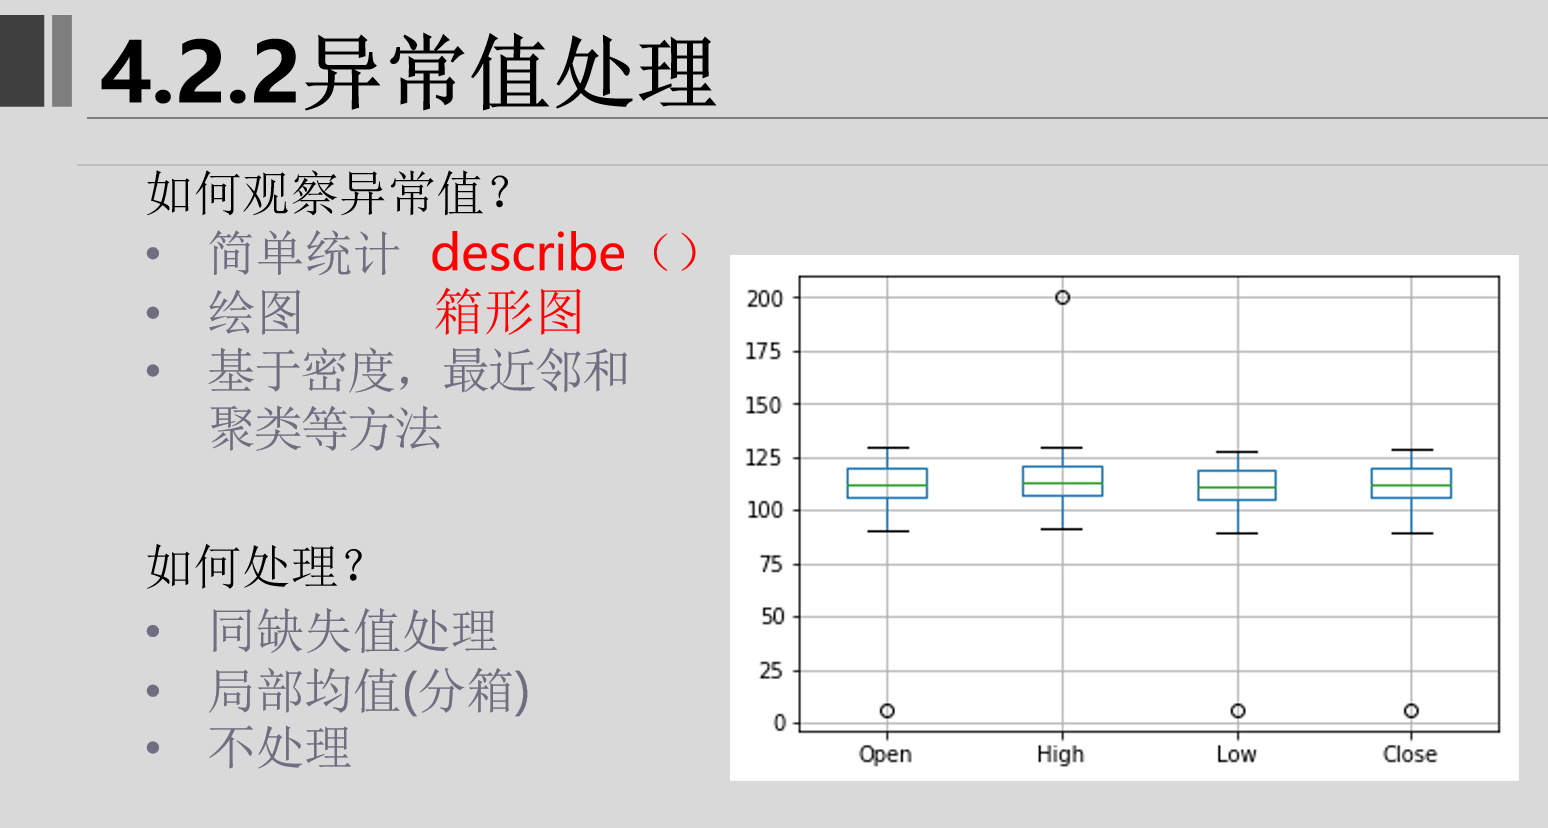
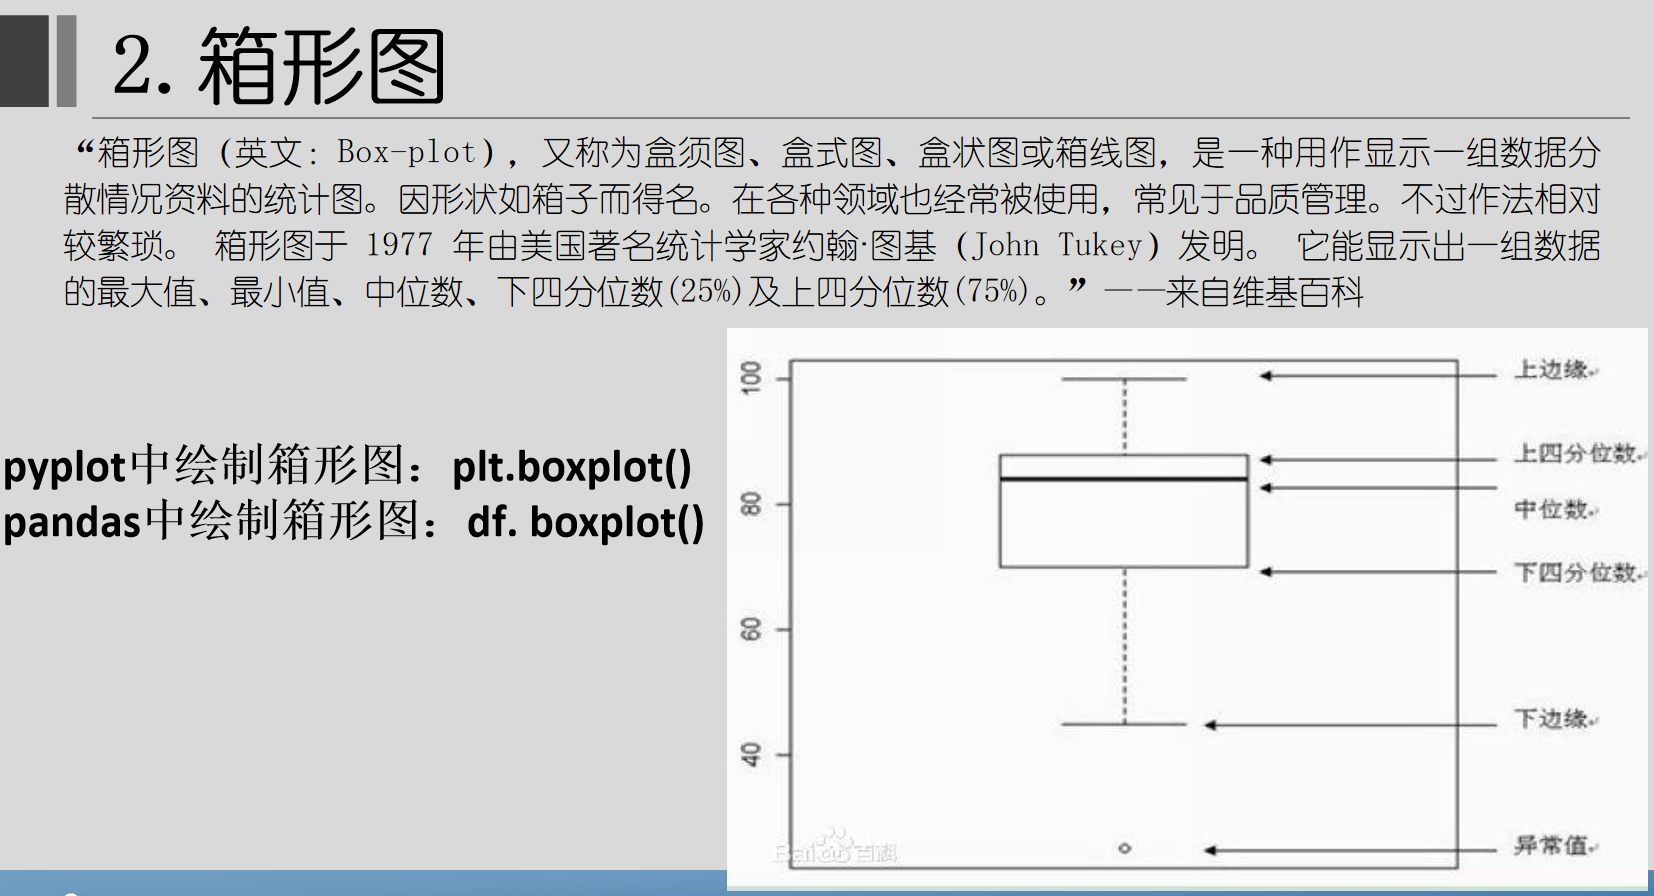

In [20]:
q1.describe()

,Open,High,Low,Close,Adj Close,Volume
count,713.000000,713.000000,713.000000,713.000000,713.000000,7.130000e+02
mean,110.737535,111.969663,109.521750,110.777770,108.520122,4.080138e+06
std,13.869086,13.760164,14.080853,13.951596,14.093340,2.163190e+06
min,72.540001,75.419998,67.000000,68.959999,67.747780,7.070000e+05
25%,100.599998,101.480003,99.510002,100.790001,97.648315,2.711400e+06
50%,109.959999,110.360001,108.709999,109.559998,106.047882,3.416100e+06
75%,120.419998,121.410004,119.519997,120.580002,118.354706,4.701900e+06
max,149.100006,151.460007,148.020004,150.270004,150.270004,1.726170e+07


# 7.增加一条记录，即日期记录最后面的一个值为[6,200,6,6,6]的记录，并取前5列的值。

In [21]:
q1.loc['2021-4-1']=[6,200,6,6,6,6]
q1

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600
2021-3-30,142.899994,144.479996,142.610001,143.490005,143.490005,2034500


In [22]:
q2=q1.iloc[:,0:5]
print(q2)

                 Open        High         Low       Close   Adj Close
Date                                                                 
2018-6-1    99.339996   99.610001   98.220001   98.250000   94.120537
2018-6-4    98.809998   99.510002   98.639999   99.449997   95.270088
2018-6-5    99.120003   99.410004   98.430000   99.309998   95.135979
2018-6-6   100.000000  101.000000   99.570000  100.970001   96.726196
2018-6-7   101.440002  102.389999  100.889999  101.480003   97.214767
...               ...         ...         ...         ...         ...
2021-3-26  143.740005  143.979996  141.050003  143.729996  143.729996
2021-3-29  141.979996  143.070007  140.309998  142.369995  142.369995
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005
2021-3-31  110.782581  143.259995  109.568093  141.440002  141.440002
2021-4-1     6.000000  200.000000    6.000000    6.000000    6.000000

[714 rows x 5 columns]


# 8.然后再进行describe(),观察有无异常。

In [23]:
print(q2.describe())

             Open        High         Low       Close   Adj Close
count  714.000000  714.000000  714.000000  714.000000  714.000000
mean   110.590844  112.092955  109.376762  110.631023  108.376537
std     14.402980   14.139660   14.594581   14.482746   14.596714
min      6.000000   75.419998    6.000000    6.000000    6.000000
25%    100.599998  101.485002   99.502500  100.774998   97.639137
50%    109.930001  110.369999  108.689999  109.559998  106.008152
75%    120.404999  121.410004  119.519997  120.572502  118.329865
max    149.100006  200.000000  148.020004  150.270004  150.270004


# 9.绘制箱形图实现各数据分布情况的可视化。  

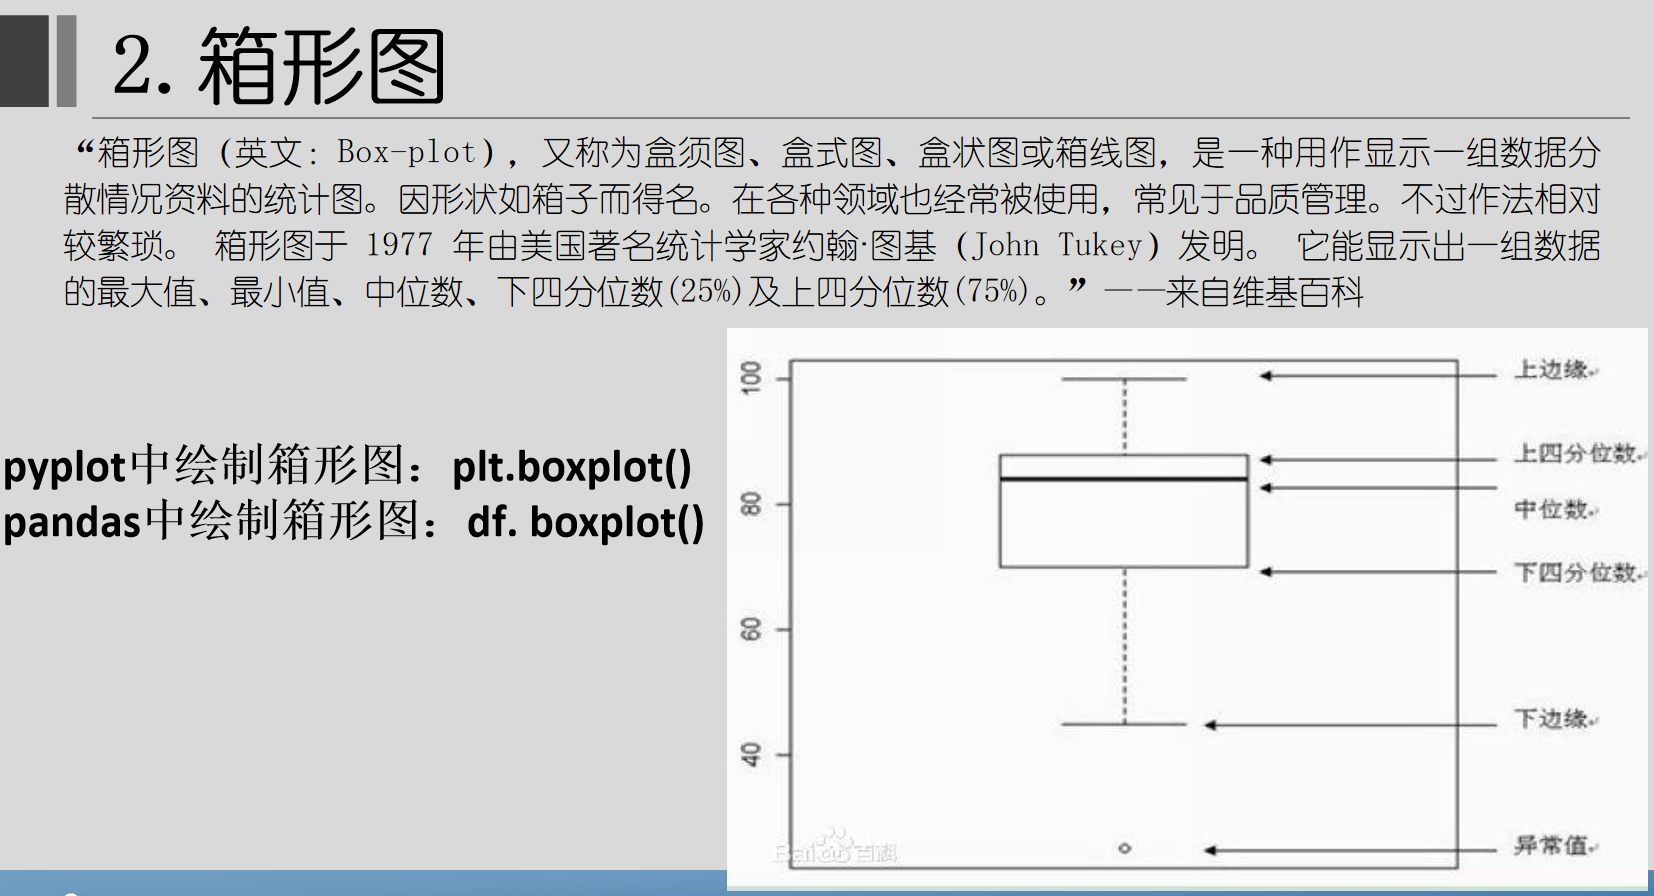

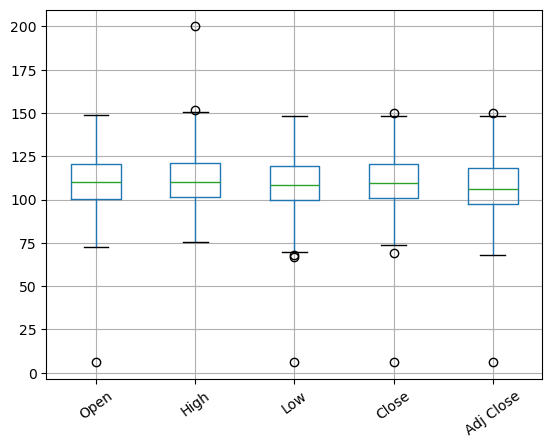

In [ ]:
q2.boxplot(rot=36)

# 10.绘制直方图实现各数据分布情况的可视化。  

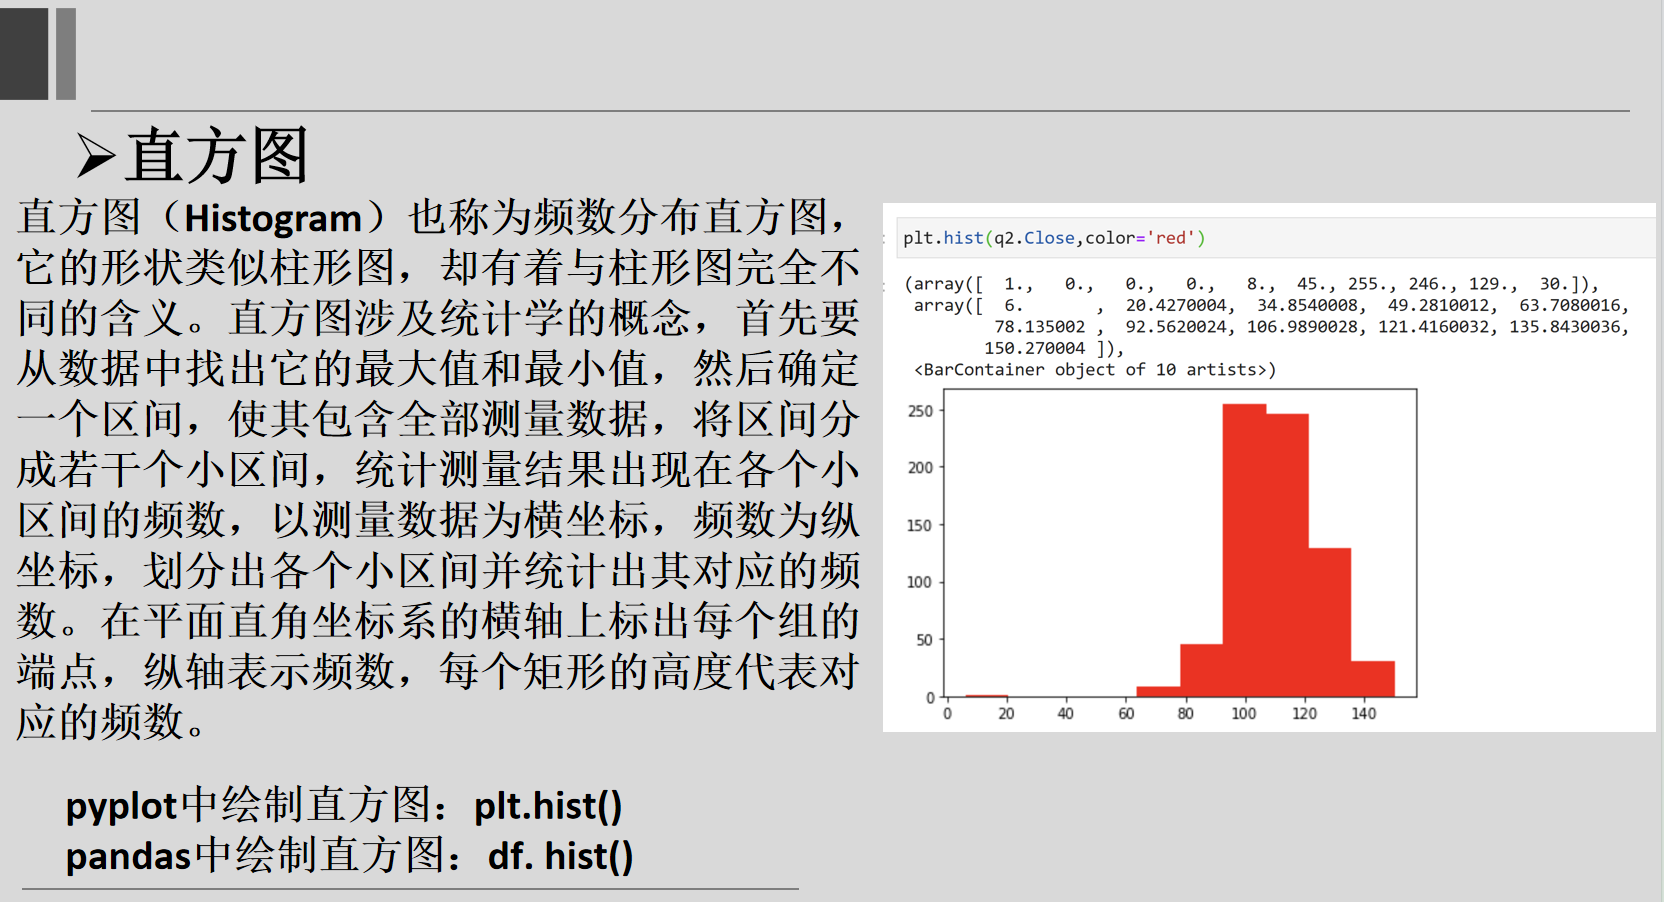

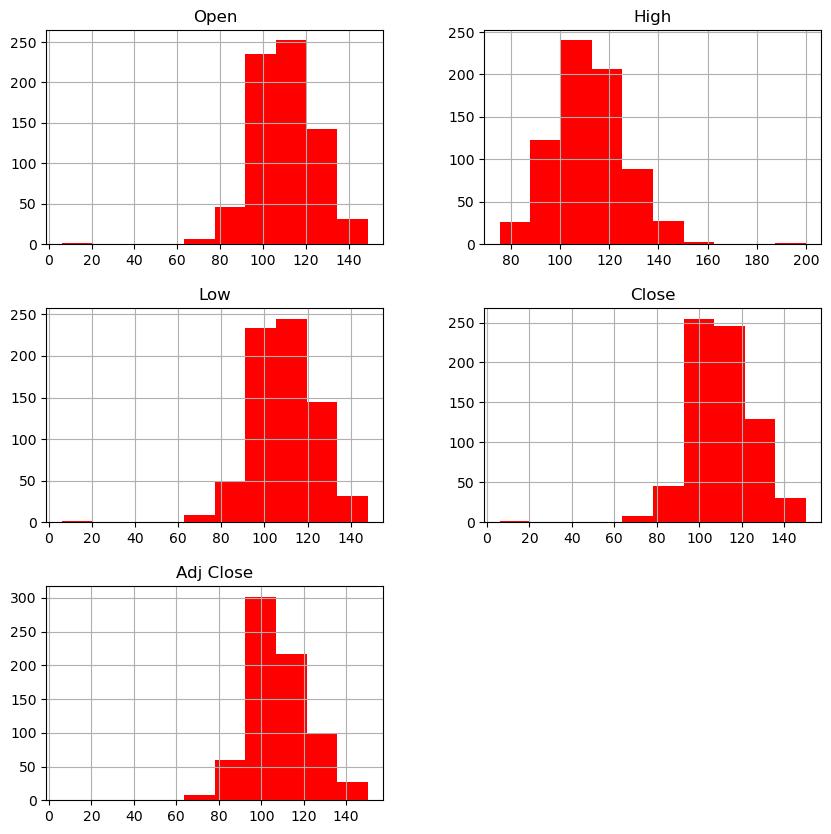

In [25]:
import matplotlib.pyplot as plt
q2.hist(figsize=(10,10),color='red')
plt.show()

In [26]:
plt.hist(q2.Close,color='red')

(array([  1.,   0.,   0.,   0.,   8.,  45., 255., 246., 129.,  30.]),
 array([  6.       ,  20.4270004,  34.8540008,  49.2810012,  63.7080016,
         78.135002 ,  92.5620024, 106.9890028, 121.4160032, 135.8430036,
        150.270004 ]),
 <BarContainer object of 10 artists>)

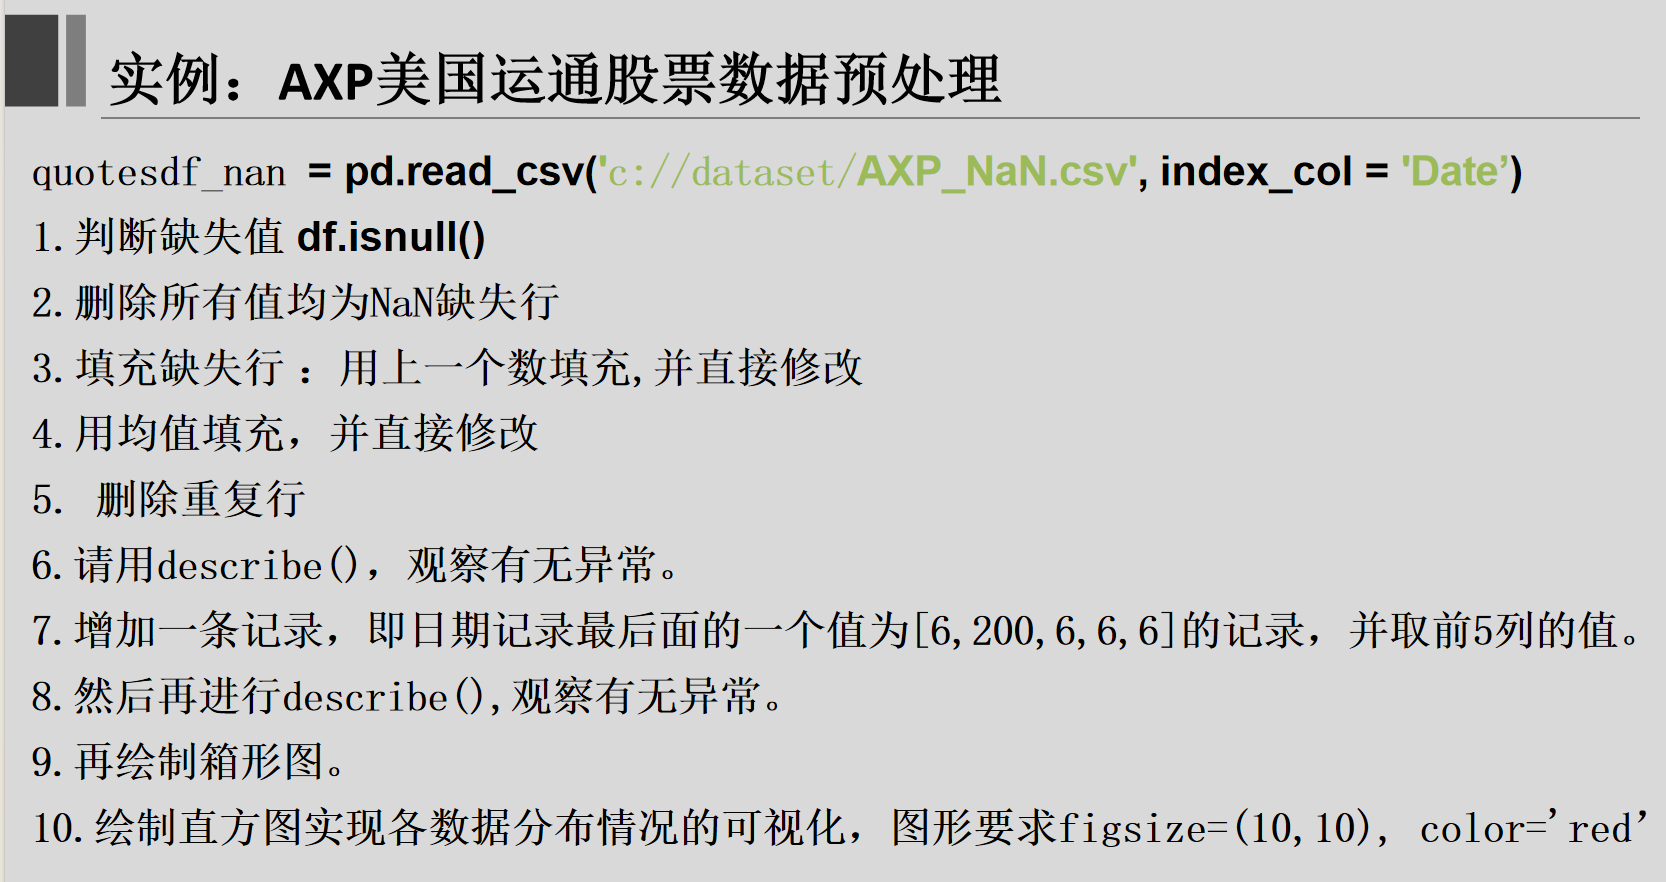
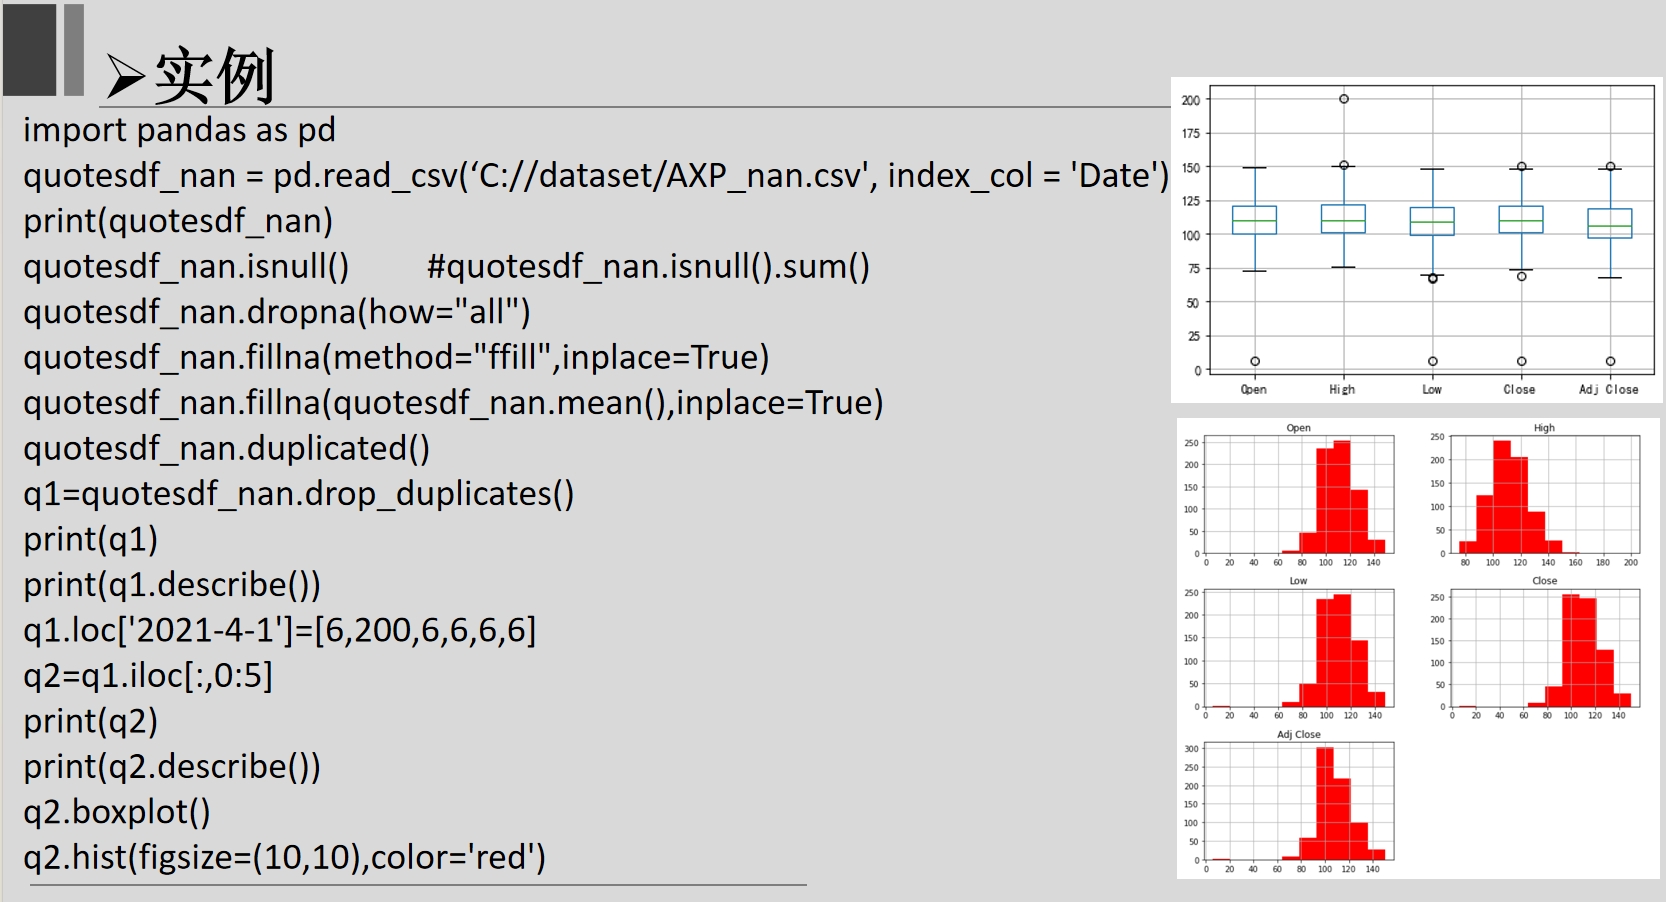

## 补充：

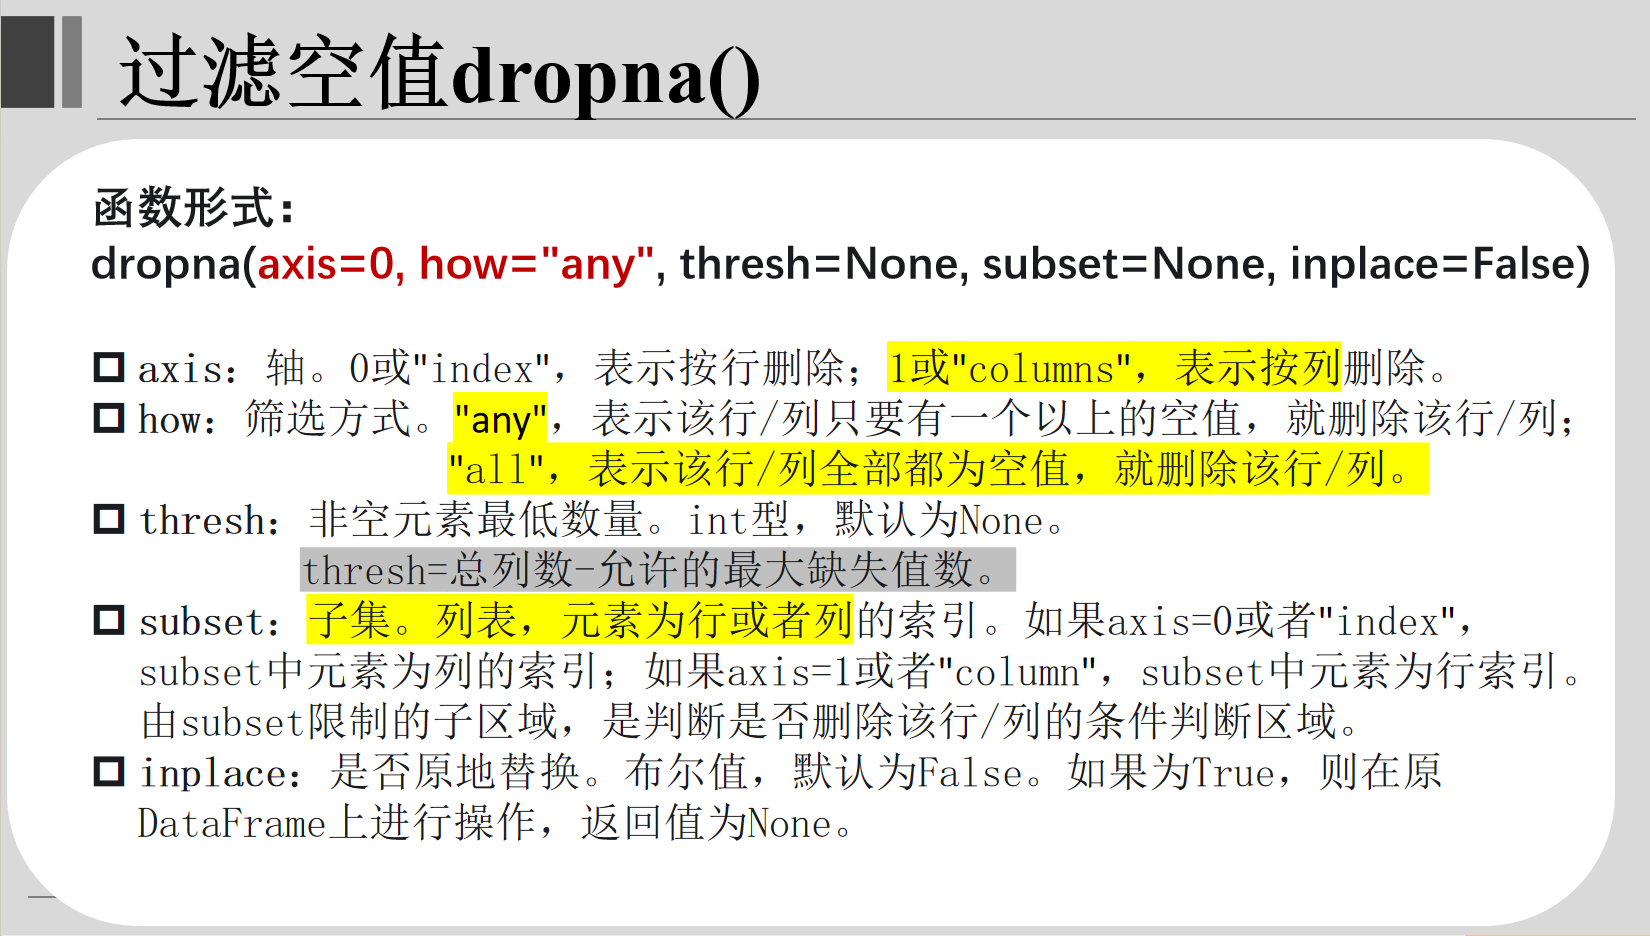

In [27]:
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'A': [1, np.nan, 4, np.nan],
    'B': [np.nan, np.nan, 5, 7],
    'C': [3, np.nan, 6, np.nan]
})
df

,A,B,C
0,1.0,NaN,3.0
1,NaN,NaN,NaN
2,4.0,5.0,6.0
3,NaN,7.0,NaN


In [28]:
#默认会删除包含缺失值的行
df.dropna() 

,A,B,C
2,4.0,5.0,6.0


In [29]:
df.dropna(axis=0,how="any")

,A,B,C
2,4.0,5.0,6.0


In [30]:
df.dropna(how="all")

,A,B,C
0,1.0,NaN,3.0
2,4.0,5.0,6.0
3,NaN,7.0,NaN


目标：删除每行中缺失值数量 ≥2 的行。

等价条件：保留每行中非缺失值数量 ≥2 的行（因为总列数为 3，允许最多 1 个缺失值）。

thresh = 总列数 - 允许的最大缺失值数 = 3 - 1 = 2

In [31]:
# 删除每行中缺失值数量 ≥2 的行
df.dropna(thresh=2)

,A,B,C
0,1.0,NaN,3.0
2,4.0,5.0,6.0


In [32]:
#删除A或C列中含有缺失值所在行。
df.dropna(subset=['A','C'])

,A,B,C
0,1.0,NaN,3.0
2,4.0,5.0,6.0


In [33]:
quotesdf_nan = pd.read_csv(file, index_col = 'Date') 
                                                    #Date列设置为索引列
print(quotesdf_nan)
quotesdf_nan.dropna( thresh=4, subset=None, inplace=True)
quotesdf_nan

                 Open        High         Low       Close   Adj Close   Volume
Date                                                                          
2018-6-1    99.339996   99.610001   98.220001   98.250000   94.120537  2711200
2018-6-4    98.809998   99.510002   98.639999   99.449997   95.270088  2417400
2018-6-5    99.120003   99.410004   98.430000   99.309998   95.135979  1811500
2018-6-6   100.000000  101.000000   99.570000  100.970001   96.726196  2872700
2018-6-7   101.440002  102.389999  100.889999  101.480003   97.214767  4245700
...               ...         ...         ...         ...         ...      ...
2021-3-26  143.740005  143.979996  141.050003  143.729996  143.729996  2687000
2021-3-29  141.979996  143.070007  140.309998  142.369995  142.369995  2220600
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-30  142.899994  144.479996  142.610001  143.490005  143.490005  2034500
2021-3-31         NaN  143.259995         NaN  141.4

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600
2021-3-30,142.899994,144.479996,142.610001,143.490005,143.490005,2034500


In [36]:
quotesdf_nan = pd.read_csv(file, index_col = 'Date') 
                                                    #Date列设置为索引列
# print(quotesdf_nan)
quotesdf_nan.dropna(subset=['Open'],inplace=True)
quotesdf_nan

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-6-1,99.339996,99.610001,98.220001,98.250000,94.120537,2711200
2018-6-4,98.809998,99.510002,98.639999,99.449997,95.270088,2417400
2018-6-5,99.120003,99.410004,98.430000,99.309998,95.135979,1811500
2018-6-6,100.000000,101.000000,99.570000,100.970001,96.726196,2872700
2018-6-7,101.440002,102.389999,100.889999,101.480003,97.214767,4245700
...,...,...,...,...,...,...
2021-3-25,137.949997,142.529999,136.759995,142.279999,142.279999,2766400
2021-3-26,143.740005,143.979996,141.050003,143.729996,143.729996,2687000
2021-3-29,141.979996,143.070007,140.309998,142.369995,142.369995,2220600
